<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/ANN_flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3958 - loss: 1.0030 - val_accuracy: 0.2917 - val_loss: 1.0391
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5729 - loss: 0.8736 - val_accuracy: 0.4583 - val_loss: 0.9512
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6354 - loss: 0.7836 - val_accuracy: 0.5417 - val_loss: 0.8881
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7188 - loss: 0.7189 - val_accuracy: 0.6667 - val_loss: 0.8357
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8646 - loss: 0.6717 - val_accuracy: 0.8750 - val_loss: 0.7868
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9167 - loss: 0.6295 - val_accuracy: 0.9167 - val_loss: 0.7407
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9062 - loss: 0.5954 - val_accuracy: 0.9167 - val_loss: 0.6978
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8958 - loss: 0.5610 - val_accuracy: 0.9167 - val_loss: 0.6562


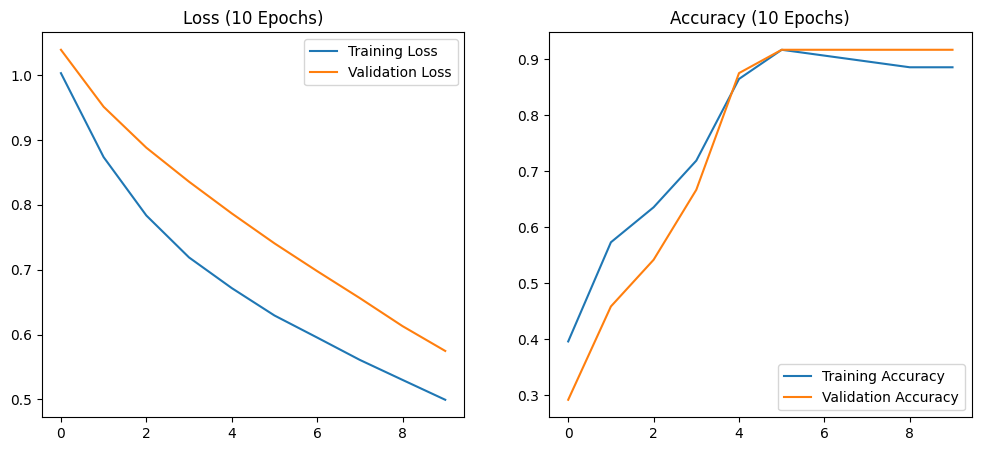

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and prepare data
iris = load_iris()
X, y = iris.data, iris.target

# One-hot encode the target labels
y = tf.keras.utils.to_categorical(y, num_classes=3)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu', name='Hidden_Layer_1'),
    Dense(32, activation='relu', name='Hidden_Layer_2'),
    Dense(3, activation='softmax', name='Output_Layer')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model for 10 epochs
history = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy after 10 epochs: {test_accuracy:.4f}. Test Loss: {test_loss:.4f}")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss (10 Epochs)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy (10 Epochs)')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Weighted F1 Score (10 epochs): 0.8960

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.67      0.80         9
   virginica       0.79      1.00      0.88        11

    accuracy                           0.90        30
   macro avg       0.93      0.89      0.89        30
weighted avg       0.92      0.90      0.90        30



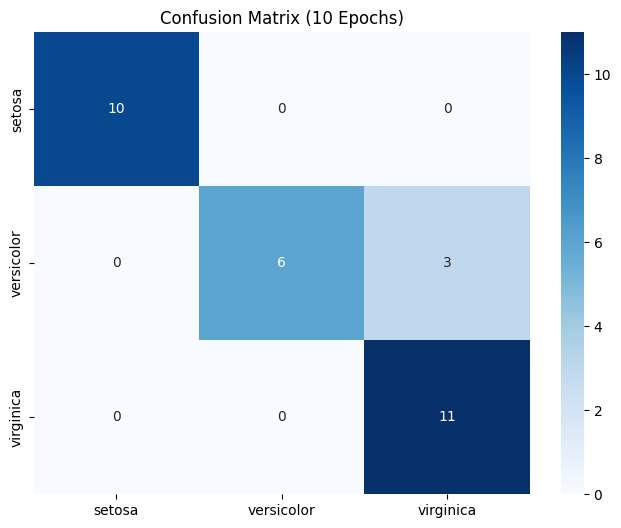

In [12]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import seaborn as sns
import pandas as pd

# Refresh predictions based on the 10-epoch model
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score (10 epochs): {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix (10 Epochs)')
plt.show()

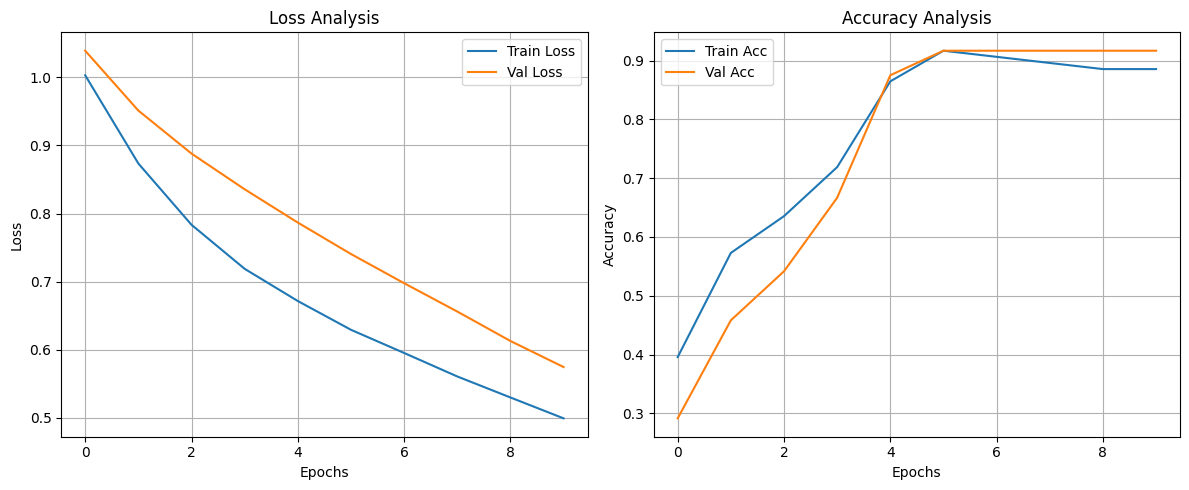

In [13]:
# Re-displaying the training curves for detailed inspection
import matplotlib.pyplot as plt

def check_overfitting(history):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Analysis')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy Analysis')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

check_overfitting(history)